# Robotic Vacuum Cleaner - ELECTRE II and Q-Bench Analysis

This notebook was reconstructed from the uploaded Colab PDF export.  
It contains a cleaned, runnable version of the ELECTRE II/Q-Bench code and reproduces the available plots:

1. Profiles of alternatives (normalized)
2. Profile of the best solution obtained with Q-Bench + ELECTRE II

The PDF source contained some broken indentation and wrapped lines due to the print/export format, so the code below has been cleaned to run correctly in Colab.


In [1]:

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")


## Data

In [2]:

# Technical criteria extracted from the PDF code
criterion_names = [
    "Motor Power", "Airflow Rate", "SLAM Acc.", "SLAM Range",
    "Path Opt.", "Auto Recharge", "Battery Cap.", "Noise",
    "Lifetime", "Setting Steps"
]

# Domain values by criterion.
# Each list contains the values associated with Competitor 1, Competitor 2, and Competitor 3.
criteria_domains = [
    [2100, 1800, 2000],  # Motor power
    [38, 33, 36],        # Airflow rate
    [2, 3, 2],           # SLAM localization accuracy
    [3, 2, 3],           # SLAM update range
    [90, 80, 88],        # Path optimization metric
    [100, 90, 110],      # Auto recharge time
    [6000, 5200, 5800],  # Battery capacity
    [68, 69, 67],        # Acoustic noise level
    [4, 4, 4],           # Component lifetime
    [3, 3, 3]            # Setting steps
]

alternative_names = ["Competitor 1", "Competitor 2", "Competitor 3"]

# Correct competitor profiles: rows = alternatives, columns = criteria
alternatives = np.array(criteria_domains, dtype=float).T.tolist()

# Weights and optimization direction extracted from the PDF code
weights = [0.007, 0.17, 0.06, 0.08, 0.08, 0.10, 0.14, 0.08, 0.19, 0.03]

# True = criterion should be minimized, False = criterion should be maximized
minimize = [False, False, False, False, False, True, False, True, False, True]

df_alternatives = pd.DataFrame(alternatives, columns=criterion_names, index=alternative_names)
df_alternatives


,Motor Power,Airflow Rate,SLAM Acc.,SLAM Range,Path Opt.,Auto Recharge,Battery Cap.,Noise,Lifetime,Setting Steps
Competitor 1,2100.0,38.0,2.0,3.0,90.0,100.0,6000.0,68.0,4.0,3.0
Competitor 2,1800.0,33.0,3.0,2.0,80.0,90.0,5200.0,69.0,4.0,3.0
Competitor 3,2000.0,36.0,2.0,3.0,88.0,110.0,5800.0,67.0,4.0,3.0


## ELECTRE II Ranking

In [3]:

def normalize_decision_matrix(X, minimize):
    """
    Normalize a decision matrix in the [0, 1] range.

    For maximization criteria:
        normalized = (x - min) / (max - min)

    For minimization criteria:
        normalized = (max - x) / (max - min)

    If all alternatives have the same value for a criterion,
    all normalized values are set to 0.5.
    """
    X = np.array(X, dtype=float)
    X_norm = np.zeros_like(X, dtype=float)

    for j in range(X.shape[1]):
        col = X[:, j]
        col_range = np.ptp(col)

        if col_range == 0:
            X_norm[:, j] = 0.5
        elif minimize[j]:
            X_norm[:, j] = (np.max(col) - col) / col_range
        else:
            X_norm[:, j] = (col - np.min(col)) / col_range

    return X_norm


def electre2_ranking(
    alternatives,
    alternative_names,
    weights,
    minimize,
    criterion_names=None,
    concordance_strong=0.70,
    discordance_strong=0.30,
    concordance_weak=0.55,
    discordance_weak=0.50,
    show_plot=True
):
    """
    ELECTRE II-style outranking procedure reconstructed from the PDF.

    Returns:
    - Concordance matrix
    - Discordance matrix
    - Strong outranking matrix
    - Weak outranking matrix
    - Ranking levels
    - Ascending order of alternatives
    """
    X = np.array(alternatives, dtype=float)
    w = np.array(weights, dtype=float)
    w = w / np.sum(w)

    m, n = X.shape

    if criterion_names is None:
        criterion_names = [f"C{i+1}" for i in range(n)]

    # --- 1. Normalization
    X_norm = normalize_decision_matrix(X, minimize)

    # --- 2. Concordance matrix
    C = np.zeros((m, m), dtype=float)
    for i in range(m):
        for k in range(m):
            if i != k:
                concordant_weights = w[X_norm[i, :] >= X_norm[k, :]]
                C[i, k] = np.sum(concordant_weights)

    # --- 3. Discordance matrix
    D = np.zeros((m, m), dtype=float)
    ranges = np.ptp(X_norm, axis=0)
    ranges[ranges == 0] = 1  # avoid division by zero

    for i in range(m):
        for k in range(m):
            if i != k:
                diff = X_norm[k, :] - X_norm[i, :]
                worse = diff > 0
                if np.any(worse):
                    D[i, k] = np.max(diff[worse] / ranges[worse])
                else:
                    D[i, k] = 0

    # --- 4. Strong and weak outranking relationships
    S_strong = (C >= concordance_strong) & (D <= discordance_strong)
    S_weak = (C >= concordance_weak) & (D <= discordance_weak)

    np.fill_diagonal(S_strong, False)
    np.fill_diagonal(S_weak, False)

    # --- 5. Ranking levels
    remaining = set(range(m))
    ranking_levels = []

    while remaining:
        # This line follows the logic visible in the PDF:
        # select alternatives that do not strongly outrank any remaining alternative.
        non_dominant = [
            i for i in remaining
            if not any(S_strong[i, j] for j in remaining)
        ]

        if not non_dominant:
            # fallback to avoid infinite loops in case of cycles
            non_dominant = [next(iter(remaining))]

        ranking_levels.append(non_dominant)
        remaining -= set(non_dominant)

    ascending_order = [i for level in ranking_levels for i in level]

    # --- 6. Plot of normalized profiles
    if show_plot:
        df = pd.DataFrame(X_norm, columns=criterion_names, index=alternative_names)
        df_long = df.reset_index().melt(
            id_vars="index",
            var_name="Criterion",
            value_name="Score"
        )
        df_long.rename(columns={"index": "Alternative"}, inplace=True)

        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=df_long,
            x="Criterion",
            y="Score",
            hue="Alternative",
            marker="o",
            linewidth=2
        )
        plt.title("Profiles of Alternatives (normalized)", fontsize=16, fontweight="bold")
        plt.ylabel("Normalized performance (0-1)")
        plt.xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="Alternative", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # --- 7. Output
    return {
        "X_norm": X_norm,
        "C": C,
        "D": D,
        "S_strong": S_strong,
        "S_weak": S_weak,
        "ranking_levels": ranking_levels,
        "ascending_order": ascending_order,
        "ascending_order_labels": [alternative_names[i] for i in ascending_order],
    }


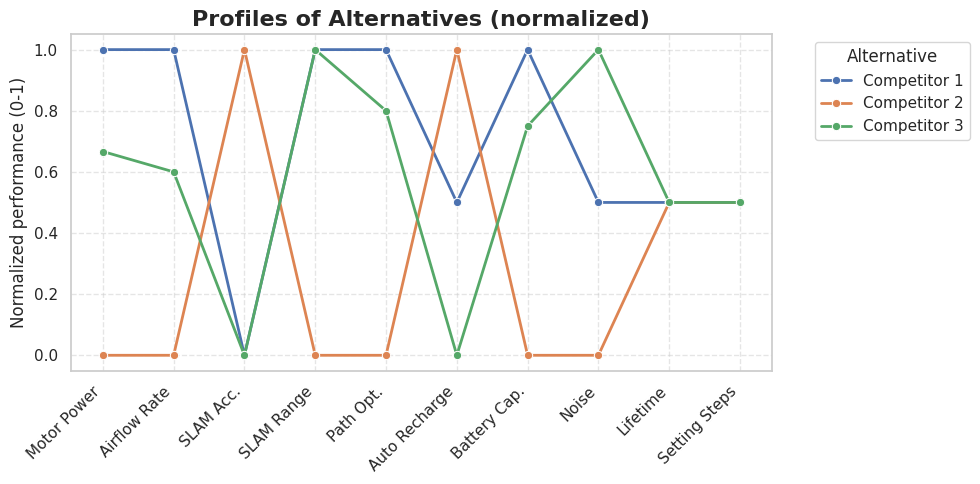

Ascending order labels: ['Competitor 1', 'Competitor 2', 'Competitor 3']


,Motor Power,Airflow Rate,SLAM Acc.,SLAM Range,Path Opt.,Auto Recharge,Battery Cap.,Noise,Lifetime,Setting Steps
Competitor 1,1.000,1.0,0.0,1.0,1.0,0.5,1.00,0.5,0.5,0.5
Competitor 2,0.000,0.0,1.0,0.0,0.0,1.0,0.00,0.0,0.5,0.5
Competitor 3,0.667,0.6,0.0,1.0,0.8,0.0,0.75,1.0,0.5,0.5


,Competitor 1,Competitor 2,Competitor 3
Competitor 1,0.000,0.829,0.915
Competitor 2,0.406,0.000,0.406
Competitor 3,0.470,0.829,0.000


,Competitor 1,Competitor 2,Competitor 3
Competitor 1,0.0,1.0,0.5
Competitor 2,1.0,0.0,1.0
Competitor 3,0.5,1.0,0.0


,Competitor 1,Competitor 2,Competitor 3
Competitor 1,False,False,False
Competitor 2,False,False,False
Competitor 3,False,False,False


In [4]:

electre_results = electre2_ranking(
    alternatives=alternatives,
    alternative_names=alternative_names,
    weights=weights,
    minimize=minimize,
    criterion_names=criterion_names,
    concordance_strong=0.70,
    discordance_strong=0.30,
    concordance_weak=0.55,
    discordance_weak=0.50,
    show_plot=True
)

print("Ascending order labels:", electre_results["ascending_order_labels"])

display(pd.DataFrame(
    electre_results["X_norm"],
    index=alternative_names,
    columns=criterion_names
).round(3))

display(pd.DataFrame(
    electre_results["C"],
    index=alternative_names,
    columns=alternative_names
).round(3))

display(pd.DataFrame(
    electre_results["D"],
    index=alternative_names,
    columns=alternative_names
).round(3))

display(pd.DataFrame(
    electre_results["S_strong"],
    index=alternative_names,
    columns=alternative_names
))


## Q-Bench + ELECTRE II

In [5]:

def electre2_outranking(
    solution1,
    solution2,
    weights,
    concordance_threshold,
    discordance_threshold,
    minimize
):
    """
    Simplified outranking function for Q-Bench, based on ELECTRE II.

    Returns True if solution1 outranks solution2, otherwise False.
    """
    X = np.array([solution1, solution2], dtype=float)
    w = np.array(weights, dtype=float)
    w = w / np.sum(w)
    m, n = X.shape

    # Normalization, simplified and based only on the two compared solutions
    X_norm = np.zeros_like(X, dtype=float)

    for j in range(n):
        col = X[:, j]

        if np.ptp(col) == 0:
            X_norm[:, j] = 0.5
        else:
            if minimize[j]:
                X_norm[:, j] = (np.max(col) - col) / np.ptp(col)
            else:
                X_norm[:, j] = (col - np.min(col)) / np.ptp(col)

    # Concordance matrix
    C = np.zeros((m, m), dtype=float)
    for i in range(m):
        for k in range(m):
            if i != k:
                concordant_weights = w[X_norm[i, :] >= X_norm[k, :]]
                C[i, k] = np.sum(concordant_weights)

    # Discordance matrix
    D = np.zeros((m, m), dtype=float)
    ranges = np.ptp(X_norm, axis=0)
    ranges[ranges == 0] = 1  # avoid division by zero

    for i in range(m):
        for k in range(m):
            if i != k:
                diff = X_norm[k, :] - X_norm[i, :]
                worse = diff > 0

                if np.any(worse):
                    D[i, k] = np.max(diff[worse] / ranges[worse])
                else:
                    D[i, k] = 0

    # Outranking relation:
    # solution1 outranks solution2 if C12 >= concordance threshold
    # and D12 <= discordance threshold.
    return C[0, 1] >= concordance_threshold and D[0, 1] <= discordance_threshold


def qbench_electre2_best_with_label(
    criteria_domains,
    alternatives,
    alternative_names,
    weights,
    concordance_threshold=0.65,
    discordance_threshold=0.35,
    minimize=None,
    criterion_names=None,
    show_plot=True,
    verbose=False
):
    """
    Q-Bench + ELECTRE II.

    Returns:
    - best technical solution
    - matching competitor label, if the solution corresponds exactly to an existing alternative
    """
    weights = np.array(weights, dtype=float) / np.sum(weights)
    n_criteria = len(criteria_domains)

    if minimize is None:
        minimize = [False] * n_criteria

    if criterion_names is None:
        criterion_names = [f"C{i+1}" for i in range(n_criteria)]

    # --- Step 1: Initialization
    current_solution = [min(domain) for domain in criteria_domains]
    best_solution = current_solution.copy()
    improved = True

    # --- Step 2: Iterative local search
    while improved:
        improved = False

        for j in np.argsort(weights)[::-1]:
            domain = criteria_domains[j]
            curr_val = current_solution[j]
            idx = domain.index(curr_val)

            if idx < len(domain) - 1:
                new_solution = current_solution.copy()
                new_solution[j] = domain[idx + 1]

                if (
                    new_solution != best_solution
                    and electre2_outranking(
                        new_solution,
                        best_solution,
                        weights,
                        concordance_threshold,
                        discordance_threshold,
                        minimize
                    )
                ):
                    best_solution = new_solution.copy()
                    current_solution = new_solution.copy()
                    improved = True

                    if verbose:
                        print(f"Improved via criterion {criterion_names[j]}: {new_solution}")

                    break

    if verbose:
        print(f"\nFinal solution: {best_solution}")

    # --- Step 3: Identify the matching competitor, if any
    best_label = None

    for alt, name in zip(alternatives, alternative_names):
        alt_profile = alt if isinstance(alt, list) else [alt]

        if np.array_equal(alt_profile, best_solution):
            best_label = name
            break

    # --- Step 4: Plot of the best solution
    if show_plot:
        df = pd.DataFrame([best_solution], columns=criterion_names)
        df["Solution"] = ["Best Solution"]
        df_long = df.melt(
            id_vars="Solution",
            var_name="Criterion",
            value_name="Score"
        )

        plt.figure(figsize=(12, 6))
        sns.lineplot(
            data=df_long,
            x="Criterion",
            y="Score",
            hue="Solution",
            marker="o",
            linewidth=3
        )
        plt.title("Profile of Best Solution (QBench + ELECTRE II)", fontsize=15, fontweight="bold")
        plt.ylabel("Criterion Value")
        plt.xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="", loc="upper left")
        plt.tight_layout()
        plt.show()

    return best_solution, best_label


Improved via criterion Airflow Rate: [1800, 36, 2, 2, 80, 90, 5200, 67, 4, 3]
Improved via criterion Battery Cap.: [1800, 36, 2, 2, 80, 90, 5800, 67, 4, 3]
Improved via criterion Path Opt.: [1800, 36, 2, 2, 88, 90, 5800, 67, 4, 3]
Improved via criterion SLAM Range: [1800, 36, 2, 3, 88, 90, 5800, 67, 4, 3]
Improved via criterion SLAM Acc.: [1800, 36, 3, 3, 88, 90, 5800, 67, 4, 3]
Improved via criterion Motor Power: [2000, 36, 3, 3, 88, 90, 5800, 67, 4, 3]

Final solution: [2000, 36, 3, 3, 88, 90, 5800, 67, 4, 3]


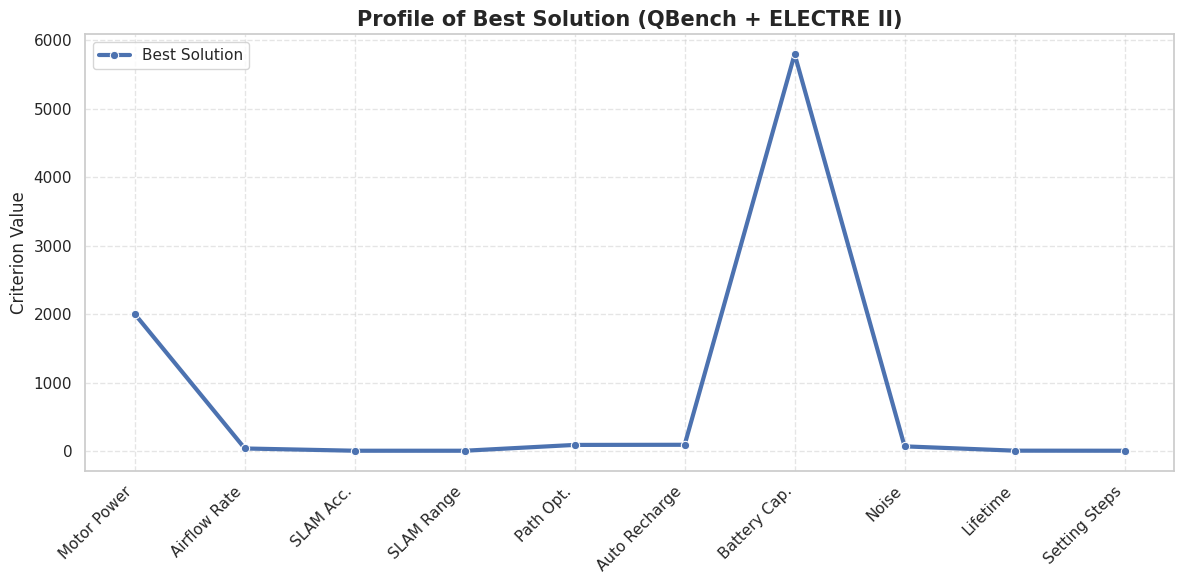

Best solution found: [2000, 36, 3, 3, 88, 90, 5800, 67, 4, 3]
Matching competitor: No exact competitor match


,Motor Power,Airflow Rate,SLAM Acc.,SLAM Range,Path Opt.,Auto Recharge,Battery Cap.,Noise,Lifetime,Setting Steps
Best Solution,2000,36,3,3,88,90,5800,67,4,3


In [6]:

best_solution, best_label = qbench_electre2_best_with_label(
    criteria_domains=criteria_domains,
    alternatives=alternatives,
    alternative_names=alternative_names,
    weights=weights,
    concordance_threshold=0.7,
    discordance_threshold=0.3,
    minimize=minimize,
    criterion_names=criterion_names,
    show_plot=True,
    verbose=True
)

print("Best solution found:", best_solution)
print("Matching competitor:", best_label if best_label is not None else "No exact competitor match")

display(pd.DataFrame([best_solution], columns=criterion_names, index=["Best Solution"]))


## Notes

- The code was reconstructed from a PDF export of a Colab notebook.
- The PDF export split and distorted some code lines, especially indentation and one competitor-profile line.
- The notebook keeps the same analytical logic and reproduces the available outputs and plots.
